# EfficientNetV2-S — LoRA
Replace eligible (non-depthwise) conv layers with LoRA wrappers; train LoRA weights + head.

In [1]:
import os

os.chdir("..")  
print(os.getcwd())
import torch
import torch.nn as nn
import torchvision.models as models
import loralib as lora
from torchvision.models import EfficientNet_V2_S_Weights

from helpers import (
    get_food101_loaders, replace_module_by_name, to_int,
    run_training, plot_results, count_trainable_params
)

/Users/peter/Documents/MDS_UBC/DATA_586/food_classification


In [2]:
def build_efficientnet_lora(num_classes: int = 101, r: int = 8, alpha: int = 16):
    model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    for name, module in list(model.named_modules()):
        if not (isinstance(module, nn.Conv2d) and name.startswith("features")):
            continue
        if module.groups != 1:          # skip depthwise convs
            continue

        new_layer = lora.Conv2d(
            in_channels=module.in_channels,
            out_channels=module.out_channels,
            kernel_size=to_int(module.kernel_size),
            stride=to_int(module.stride),
            padding=to_int(module.padding),
            dilation=to_int(module.dilation),
            groups=module.groups,
            bias=(module.bias is not None),
            r=r, lora_alpha=alpha,
        )
        new_layer.conv.weight.data.copy_(module.weight.data)
        if module.bias is not None:
            new_layer.conv.bias.data.copy_(module.bias.data)
        replace_module_by_name(model, name, new_layer)

    lora.mark_only_lora_as_trainable(model)
    for p in model.classifier[1].parameters():
        p.requires_grad = True

    return model

In [3]:
weights   = EfficientNet_V2_S_Weights.DEFAULT
transform = weights.transforms()

train_loader, val_loader = get_food101_loaders(transform, batch_size=32, num_workers=4)

model = build_efficientnet_lora(num_classes=101, r=8, alpha=16)
print(f"Trainable params: {count_trainable_params(model):,}")

Trainable params: 1,511,997


In [4]:
model, train_losses, val_losses, train_accs, val_accs = run_training(
    model=model,
    model_name="efficientnet_lora",
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=8,
    lr=1e-3,
)

[efficientnet_lora] Final checkpoint found — loading metrics for plotting.


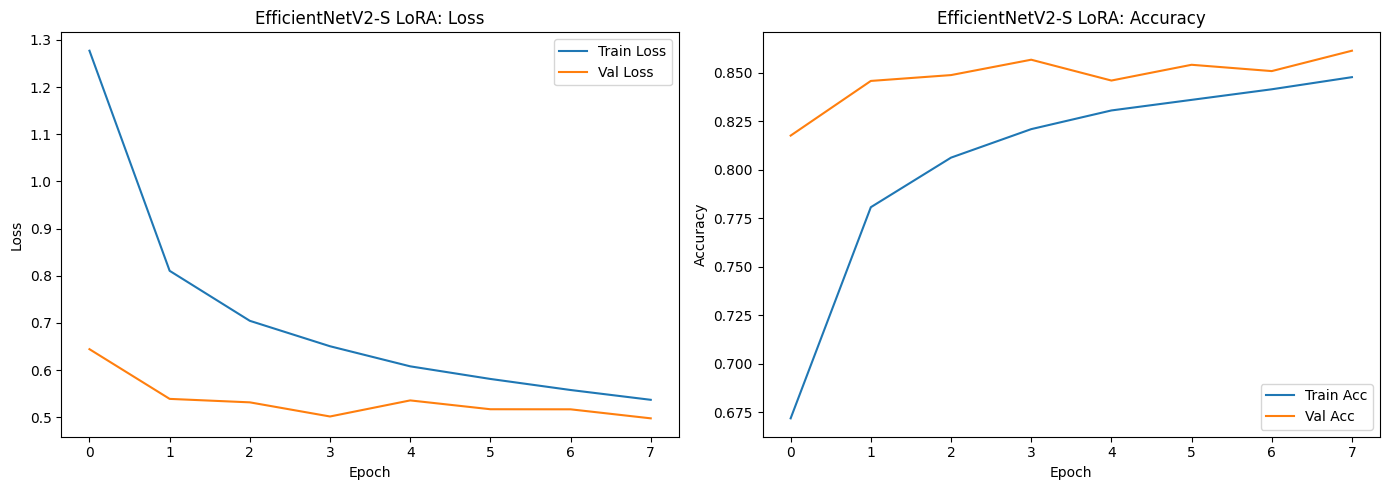

In [5]:
plot_results(train_losses, val_losses, train_accs, val_accs, "EfficientNetV2-S LoRA")